In [1]:
import sys
from pathlib import Path
from copy import copy

import numpy as np
import pandas as pd
import cv2 as cv
from cv2.typing import MatLike, TermCriteria
import matplotlib.pyplot as plt
from matplotlib import __version__ as matplotlib_version
import seaborn as sns

from utils.imageio import read_images
from utils.evaluate_metrics import evaluate_metrics
from utils.pipeline import ImagePipeline, ImageState
from utils.types import ArrayLike, Tensors

In [2]:
print(f"Using python version: {sys.version}")
print(f"Using numpy version: {np.__version__}")
print(f"Using opencv version: {cv.__version__}")
print(f"Using matplotlib version {matplotlib_version}")
print(f"Using seaborn version {sns.__version__}") # type: ignore


Using python version: 3.12.12 (main, Feb 12 2026, 00:42:34) [Clang 21.1.4 ]
Using numpy version: 2.4.3
Using opencv version: 4.13.0
Using matplotlib version 3.10.8
Using seaborn version 0.13.2


In [3]:
DATA_PATH = Path("../datasets/EWS-Dataset")
TRAIN_PATH = DATA_PATH / "train"
VAL_PATH = DATA_PATH / "validation"
TEST_PATH = DATA_PATH / "test"

LOWER_GREEN = np.array([35, 40, 40])
UPPER_GREEN = np.array([90, 255, 255])

In [4]:
train_x, train_y = read_images(TRAIN_PATH)
val_x, val_y = read_images(VAL_PATH)
test_x, test_y = read_images(TEST_PATH)
print(train_x[0].shape)
assert len(val_x) == len(val_y)
assert len(train_x) == len(train_y)
assert len(test_x) == len(test_y)

(350, 350, 3)


### Traditional CV

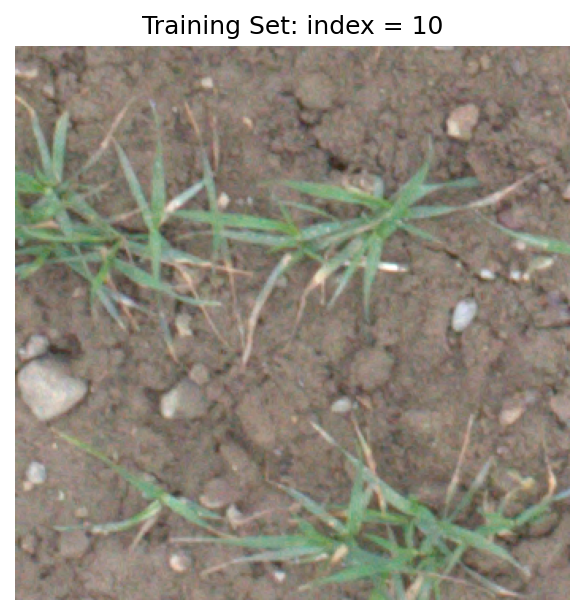

In [5]:
train_pipeline = ImagePipeline(train_x, ImageState.RGB, "Training Set")
train_y_pipeline = ImagePipeline(train_y, ImageState.BINARY, "Training Y")
val_pipeline = ImagePipeline(val_x, ImageState.RGB, "Validation Set")
test_pipeline = ImagePipeline(test_x, ImageState.RGB, "Test Set")

train_pipeline.show(10)

In [ ]:
def hsv_segmentation(
        pipeline: ImagePipeline,
        lower: MatLike,
        upper: MatLike,
        kernel_size: tuple[int, int],
        iters: int
    ) -> ImagePipeline:
    assert pipeline.image_state == ImageState.RGB
    processing_pipeline = pipeline.copy()
    return processing_pipeline.rgb_to_hsv() \
        .in_color_range(lower, upper) \
        .opening(kernel_size, iters=iters) \
        .closing(kernel_size, iters=iters)

hsv_segmented_train = hsv_segmentation(train_pipeline, LOWER_GREEN, UPPER_GREEN, (3, 3), 1)
hsv_segmented_val = hsv_segmentation(val_pipeline, LOWER_GREEN, UPPER_GREEN, (3, 3), 1)
hsv_segmented_test = hsv_segmentation(test_pipeline, LOWER_GREEN, UPPER_GREEN, (3, 3), 1)


_ = evaluate_metrics(hsv_segmented_train.images, train_y, print_metrics=True, custom_title="HSV Train")
_ = evaluate_metrics(hsv_segmented_val.images, val_y, print_metrics=True, custom_title="HSV Validation")
_ = evaluate_metrics(hsv_segmented_test.images, test_y, print_metrics=True, custom_title="HSV Test")


Evaluation Result for **HSV Train**:

True Positive: 2519636
True Negative: 13527608
False Positive: 214860
False Negative: 1132896

Accuracy: 0.92
Precision: 0.92
Recall: 0.69
F1: 0.79


Evaluation Result for **HSV Validation**:

True Positive: 717503
True Negative: 1971872
False Positive: 52760
False Negative: 197865

Accuracy: 0.91
Precision: 0.93
Recall: 0.78
F1: 0.85


Evaluation Result for **HSV Test**:

True Positive: 730575
True Negative: 1919240
False Positive: 57067
False Negative: 233118

Accuracy: 0.90
Precision: 0.93
Recall: 0.76
F1: 0.83



In [7]:
def kmeans_method(
        processing_pipeline: ImagePipeline,
        k: int,
        criteria: TermCriteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 10, 1.0)
        ) -> ImagePipeline:
    return processing_pipeline.k_means_clustering(k, criteria)

kmeans_segmented_train = kmeans_method(train_pipeline, k=2)
kmeans_segmented_val = kmeans_method(val_pipeline, k=2)
kmeans_segmented_test = kmeans_method(test_pipeline, k=2)


_ = evaluate_metrics(kmeans_segmented_train.images, train_y, print_metrics=True, custom_title="K-means Train")
_ = evaluate_metrics(kmeans_segmented_val.images, val_y, print_metrics=True, custom_title="K-means Validation")
_ = evaluate_metrics(kmeans_segmented_test.images, test_y, print_metrics=True, custom_title="K-means Test")


Evaluation Result for **K-means Train**:

True Positive: 1816183
True Negative: 8135556
False Positive: 5606912
False Negative: 1836349

Accuracy: 0.57
Precision: 0.24
Recall: 0.50
F1: 0.33


Evaluation Result for **K-means Validation**:

True Positive: 353700
True Negative: 1319254
False Positive: 705378
False Negative: 561668

Accuracy: 0.57
Precision: 0.33
Recall: 0.39
F1: 0.36


Evaluation Result for **K-means Test**:

True Positive: 354890
True Negative: 1134807
False Positive: 841500
False Negative: 608803

Accuracy: 0.51
Precision: 0.30
Recall: 0.37
F1: 0.33



In [8]:
def edge_method(
        process_pipeline: ImagePipeline,
        blur_ksize: tuple[int, int] = (5, 5),
        blur_stddev: float = 1.4,
        edge_th1: int = 60,
        edge_th2: int = 150,
        closing_ksize: tuple[int, int] = (3, 3),
        closing_iter = 5,
        remove_object_size = 1000
    ) -> ImagePipeline:

    return process_pipeline \
        .gaussian_blur(blur_ksize, blur_stddev) \
        .canny_edge_detect(edge_th1, edge_th2) \
        .closing(closing_ksize, closing_iter) \
        .remove_small_object(remove_object_size)

edge_segmented_train = edge_method(train_pipeline)
edge_segmented_val = edge_method(val_pipeline)
edge_segmented_test = edge_method(test_pipeline)

_ = evaluate_metrics(edge_segmented_train.images, train_y, print_metrics=True, custom_title="Edge Train Set")
_ = evaluate_metrics(edge_segmented_val.images, val_y, print_metrics=True, custom_title="Edge Validation Set")
_ = evaluate_metrics(edge_segmented_test.images, test_y, print_metrics=True, custom_title="Edge Test Set")


Evaluation Result for **Edge Train Set**:

True Positive: 2094179
True Negative: 8912573
False Positive: 4829895
False Negative: 1558353

Accuracy: 0.63
Precision: 0.30
Recall: 0.57
F1: 0.40


Evaluation Result for **Edge Validation Set**:

True Positive: 430399
True Negative: 1364469
False Positive: 660163
False Negative: 484969

Accuracy: 0.61
Precision: 0.39
Recall: 0.47
F1: 0.43


Evaluation Result for **Edge Test Set**:

True Positive: 447076
True Negative: 1251116
False Positive: 725191
False Negative: 516617

Accuracy: 0.58
Precision: 0.38
Recall: 0.46
F1: 0.42



In [ ]:
def exessive_green_method(process_pipeline: ImagePipeline, threshold: int = 20, remove_object_size: int = 100) -> ImagePipeline:
    return process_pipeline \
        .excessive_green_mask(threshold) \
        .remove_small_object(remove_object_size)

ExG_segmented_train = exessive_green_method(train_pipeline)
ExG_segmented_val = exessive_green_method(val_pipeline)
ExG_segmented_test = exessive_green_method(test_pipeline)

_ = evaluate_metrics(ExG_segmented_train.images, train_y, print_metrics=True, custom_title="ExG Train Set")
_ = evaluate_metrics(ExG_segmented_val.images, val_y, print_metrics=True, custom_title="ExG Validation Set")
_ = evaluate_metrics(ExG_segmented_test.images, test_y, print_metrics=True, custom_title="ExG Test Set")


Evaluation Result for **ExG Train Set**:

True Positive: 3059292
True Negative: 13133964
False Positive: 608504
False Negative: 593240

Accuracy: 0.93
Precision: 0.83
Recall: 0.84
F1: 0.84


Evaluation Result for **ExG Validation Set**:

True Positive: 827878
True Negative: 1877689
False Positive: 146943
False Negative: 87490

Accuracy: 0.92
Precision: 0.85
Recall: 0.90
F1: 0.88


Evaluation Result for **ExG Test Set**:

True Positive: 873314
True Negative: 1794749
False Positive: 181558
False Negative: 90379

Accuracy: 0.91
Precision: 0.83
Recall: 0.91
F1: 0.87

